<a href="https://colab.research.google.com/github/guebin/DL2026/blob/master/posts/08wk.ipynb"><img src="https://colab.research.google.com/assets/colab-badge.svg" style="text-align: left"></a>

# 1. 강의영상

In [1]:
# {{<video https://youtu.be/playlist?list=PLQqh36zP38-xB7p8AzMKUrEfxL0Vte-pY&si=BwVUNxT8IIPrjIcA>}}

# 2. Imports

In [1]:
import torch
import torchvision
import matplotlib.pyplot as plt

In [2]:
plt.rcParams['figure.figsize'] = (4.5,3.0)

# 3. MNIST 3/7

## A. 예비학습 -- `plt.imshow()`

`-` `plt.imshow(..., cmap="gray")` 에서 `...`이 shape이 (??,??)이면 흑백이미지를 출력

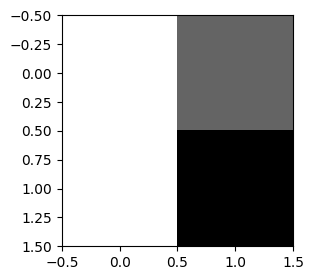

In [3]:
img = torch.tensor([[255,100],
                    [255,0]])
plt.imshow(img,cmap="gray")

`-` `plt.imshow(...)` 에서 `...`의 shape이 (??,??,3)이면 칼라이미지를 출력

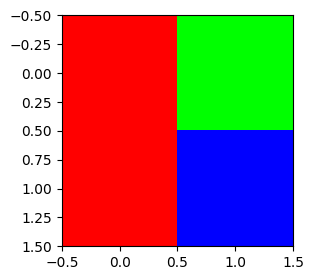

In [4]:
r = torch.tensor([[255,0],
                  [255,0]])
g = torch.tensor([[0,255],
                  [0,0]])
b = torch.tensor([[0,0],
                  [0,255]])
img = torch.stack([r,g,b],axis=-1)
plt.imshow(img)

`-` `plt.imshow(...)` 에서 `...`의 자료형이 int인지 float인지에 따라서 인식이 다름

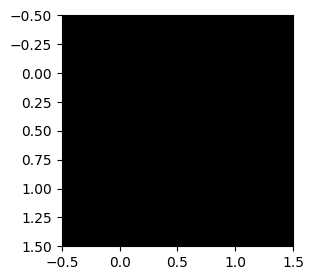

In [5]:
r = torch.tensor([[1,0],
                  [1,0]])
g = torch.tensor([[0,1],
                  [0,0]])
b = torch.tensor([[0,0],
                  [0,1]])
img = torch.stack([r,g,b],axis=-1)
plt.imshow(img)

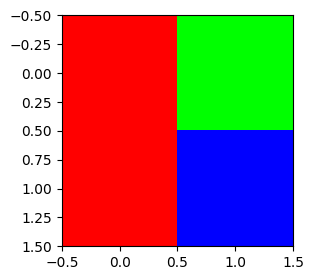

In [6]:
r = torch.tensor([[255,0],
                  [255,0]])/255
g = torch.tensor([[0,255],
                  [0,0]])/255
b = torch.tensor([[0,0],
                  [0,255]])/255
img = torch.stack([r,g,b],axis=-1)
plt.imshow(img)

## B. 데이터

`-` 데이터 정리코드

In [ ]:
train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True)
to_tensor = torchvision.transforms.ToTensor()
X3 = torch.stack([to_tensor(Xi) for Xi, yi in train_dataset if yi==3])
X7 = torch.stack([to_tensor(Xi) for Xi, yi in train_dataset if yi==7])
X = torch.concat([X3,X7],axis=0)
y = torch.tensor([0.0]*len(X3) + [1.0]*len(X7))

100.0%
100.0%
100.0%
100.0%


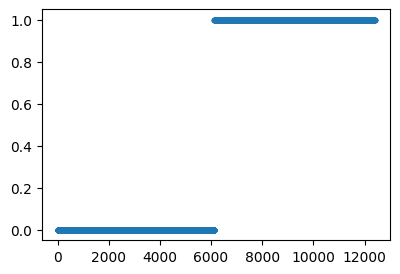

In [8]:
plt.plot(y,'.')

`-` 우리는 ${\bf X}: (n,1,28,28)$ 에서 ${\bf y}: (n,1)$으로 가는 맵핑을 배우고 싶음. $\to$ 이런건 배운적이 없는데?.. $\to$ 그렇다면 ${\bf X}:(n,784) \to {\bf y}:(n,1)$ 으로 가는 맵핑을 학습하자.

In [11]:
X = torch.stack([img.reshape(-1) for img in X])
Y = y.reshape(-1,1)

In [12]:
X.shape,y.shape

(torch.Size([12396, 784]), torch.Size([12396]))

## C. 학습

In [24]:
net = torch.nn.Sequential(
    torch.nn.Linear(784,32),
    torch.nn.ReLU(),
    torch.nn.Linear(32,1),
    torch.nn.Sigmoid()
)
loss_fn = torch.nn.BCELoss()
optimizer = torch.optim.Adam(net.parameters())
#---#
for epoch in range(200):
    ## 1 
    Yhat = net(X) 
    ## 2 
    loss = loss_fn(Yhat,Y)
    ## 3
    loss.backward()
    ## 4 
    optimizer.step()
    optimizer.zero_grad()

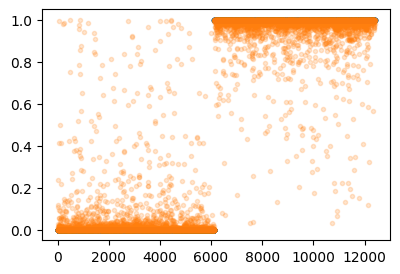

In [25]:
plt.plot(Y,'.')
plt.plot(net(X).data,'.',alpha=0.2)

In [26]:
((Y == (net(X).data > 0.5))*1.0).mean()

tensor(0.9893)

`*` 이미지자료의 차원

- 칼라이미지데이터 ${\bf X}$는 (n,3,h,w) 의 차원을 가지거나 (n,h,w,3)의 차원을 가진다. 
- 흑백이미지데이터 ${\bf X}$는 (n,h,w) 의 차원을 가지거나 (n,1,h,w)의 차원을 가지거나 (n,h,w,1)의 차원을 가진다. 

# 4. 오버피팅 (시벤코정리의 이면)

> 시벤코정리는 무적인가? 

## A. 오버피팅

`-` 오버피팅이란? 

- 위키: In mathematical modeling, overfitting is "the production of an analysis that corresponds too closely or exactly to a particular set of data, and may therefore fail to fit to additional data or predict future observations reliably". (수학적 모델링에서 과적합이란 "어떤 모델이 주어진 데이터에 너무 꼭 맞춰져 있어서, 새로운 데이터나 미래의 결과를 잘 예측하지 못할 수 있는 상태"를 의미한다.)
- 제 개념: 데이터를 "데이터 = 언더라잉 + 오차"라고 생각할때 우리가 데이터로부터 적합할 것은 언더라잉인데 오차항을 적합하고 있는 현상. 

## B. 오버피팅 예시

`-` $m$이 매우 클때 아래의 네트워크 거의 무엇이든 맞출 수 있다고 보면 된다. 

- $\underset{(n,1)}{\bf X} \overset{l_1}{\to} \underset{(n,m)}{\boldsymbol u^{(1)}} \overset{h}{\to} \underset{(n,m)}{\boldsymbol v^{(1)}} \overset{l_2}{\to} \underset{(n,1)}{\hat{\boldsymbol y}}$ 
- $\underset{(n,1)}{\bf X} \overset{l_1}{\to} \underset{(n,m)}{\boldsymbol u^{(1)}} \overset{sig}{\to} \underset{(n,m)}{\boldsymbol v^{(1)}} \overset{l_2}{\to} \underset{(n,1)}{\hat{\boldsymbol y}}$
- $\underset{(n,1)}{\bf X} \overset{l_1}{\to} \underset{(n,m)}{\boldsymbol u^{(1)}} \overset{relu}{\to} \underset{(n,m)}{\boldsymbol v^{(1)}} \overset{l_2}{\to} \underset{(n,1)}{\hat{\boldsymbol y}}$

`-` 그런데 종종 맞추지 말아야 할 것들도 맞춘다. 

$$\text{model:} \quad y_i = (0\times x_i) + \epsilon_i,~~ \text{where}~ \epsilon_i \sim N(0,0.01^2)$$

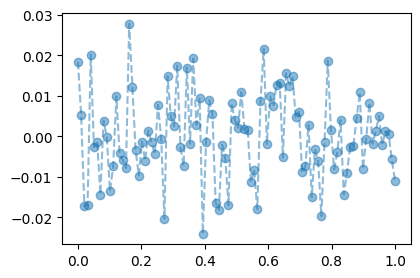

In [ ]:
torch.manual_seed(5) 
x = torch.linspace(0,1,100).reshape(100,1)
y = torch.randn(100).reshape(100,1)*0.01
plt.plot(x,y,'--o',alpha=0.5)

In [ ]:
torch.manual_seed(1)
net = torch.nn.Sequential(
    torch.nn.Linear(1,512),
    torch.nn.ReLU(),
    torch.nn.Linear(512,1)
)
loss_fn = torch.nn.MSELoss()
optimizr = torch.optim.Adam(net.parameters())
#---#
for epoc in range(1000):
    ## step1 
    yhat = net(x) 
    ## step2 
    loss = loss_fn(yhat,y)
    ## step3 
    loss.backward()
    ## step4 
    optimizr.step()
    optimizr.zero_grad()

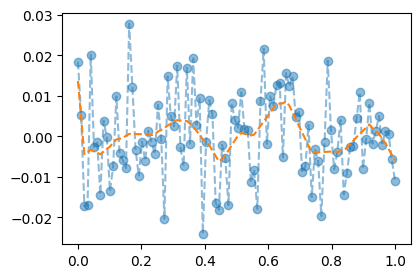

In [ ]:
plt.plot(x,y,'--o',alpha=0.5)
plt.plot(x,net(x).data,'--')

## C. 오버피팅이라는 뚜렷한 증거! (train / test)

`-` 데이터의 분리하여 보자. 

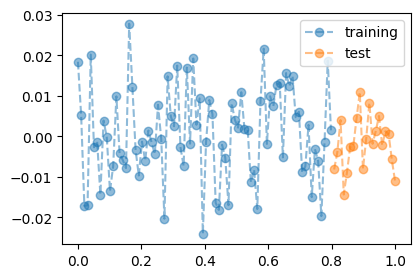

In [ ]:
torch.manual_seed(5) 
x_all = torch.linspace(0,1,100).reshape(100,1)
y_all = torch.randn(100).reshape(100,1)*0.01
x,xx = x_all[:80], x_all[80:]
y,yy = y_all[:80], y_all[80:]
plt.plot(x,y,'--o',alpha=0.5,label="training")
plt.plot(xx,yy,'--o',alpha=0.5,label="test")
plt.legend()

`-` train만 학습

In [ ]:
torch.manual_seed(1)
net = torch.nn.Sequential(
    torch.nn.Linear(1,512),
    torch.nn.ReLU(),
    torch.nn.Linear(512,1)
)
loss_fn = torch.nn.MSELoss()
optimizr = torch.optim.Adam(net.parameters())
#---#
for epoc in range(1000):
    ## step1 
    yhat = net(x) 
    ## step2 
    loss = loss_fn(yhat,y)
    ## step3 
    loss.backward()
    ## step4 
    optimizr.step()
    optimizr.zero_grad()

`-` training data로 학습한 net를 training data 에 적용 

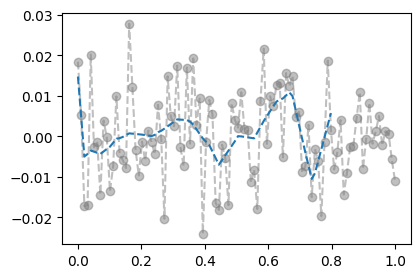

In [ ]:
plt.plot(x_all,y_all,'--o',alpha=0.5,color="gray")
plt.plot(x,net(x).data,'--')

- training에서는 그럭저럭 잘 맞춤

`-` training data로 학습한 net를 test data 에 적용 

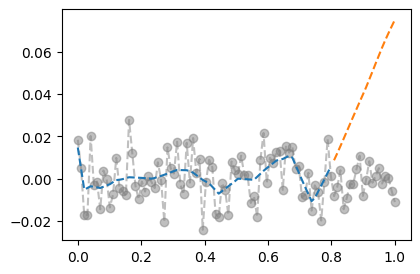

In [ ]:
plt.plot(x_all,y_all,'--o',alpha=0.5,color="gray")
plt.plot(x,net(x).data,'--')
plt.plot(xx,net(xx).data,'--')

- train에서는 그럭저럭 잘 맞추는데 test에서는 엉망이다 = overfit 

## D. 시벤코정리의 올바른 이해

`# 시벤코의 항변(?)` [@cybenko1989approximation]

하나의 은닉층을 가지는 아래와 같은 꼴의 네트워크 $net: {\bf X}_{n \times p} \to {\bf y}_{n\times q}$는

```Python
net = torch.nn.Sequential(
    torch.nn.Linear(p,???),
    torch.nn.Sigmoid(), ## <-- 여기에 렐루를 써도 된다. 
    torch.nn.Linear(???,q)
)
```

모든 보렐가측함수 

$$f: {\bf X}_{n \times p} \to {\bf y}_{n\times q}$$

를 원하는 정확도로 "근사"시킬 수 있다. 쉽게 말하면 ${\bf X} \to {\bf y}$ 인 어떠한 복잡한 규칙라도 하나의 은닉층을 가진 신경망이 원하는 정확도로 근사시킨다는 의미이다. **그렇지만 이러한 규칙이 네크워크가 학습하지 못했던 자료 (처음 보는 자료, unseen data)** ${\bf XX}_{m \times p}$, ${\bf yy}_{m \times q}$ **에 대하여서도 올바르게 적용된다라는 보장은 없다**. 시벤코는 단지 `net`가 가지는 표현력의 한계를 수학적으로 밝혔을 뿐이다. 

# 5. 드랍아웃

## A. 오버피팅의 해결 

`-` 오버피팅의 해결책: 드랍아웃 

`-` 데이터

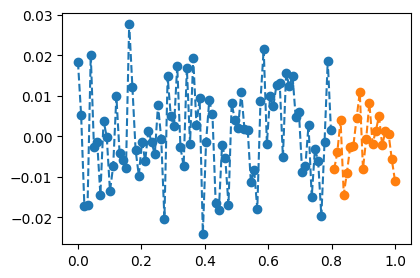

In [ ]:
torch.manual_seed(5) 
x_all = torch.linspace(0,1,100).reshape(100,1)
y_all = torch.randn(100).reshape(100,1)*0.01
#plt.plot(x_all,y_all,'--o',alpha=0.5)
x,y = x_all[:80], y_all[:80]
xx,yy = x_all[80:], y_all[80:]
plt.plot(x,y,'--o',color="C0")
plt.plot(xx,yy,'--o',color="C1")

`-` 학습

In [ ]:
torch.manual_seed(1)
net = torch.nn.Sequential(
    torch.nn.Linear(1,512),
    torch.nn.ReLU(),
    torch.nn.Dropout(0.8),
    torch.nn.Linear(512,1)
)
loss_fn = torch.nn.MSELoss()
optimizr = torch.optim.Adam(net.parameters())
#---#
for epoc in range(1000):
    ## step1 
    yhat = net(x) 
    ## step2 
    loss = loss_fn(yhat,y)
    ## step3 
    loss.backward()
    ## step4 
    optimizr.step()
    optimizr.zero_grad()

`-` 결과시각화 (잘못된 사용)

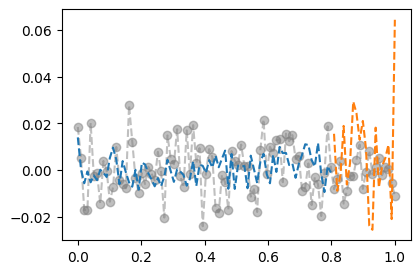

In [ ]:
plt.plot(x_all,y_all,'--o',alpha=0.5,color="gray")
plt.plot(x,net(x).data,'--')
plt.plot(xx,net(xx).data,'--')

`-` 결과시각화 (올바른 사용)

In [ ]:
net.training 

True

In [ ]:
net.eval()

Sequential(
  (0): Linear(in_features=1, out_features=512, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.8, inplace=False)
  (3): Linear(in_features=512, out_features=1, bias=True)
)

In [ ]:
net.training

False

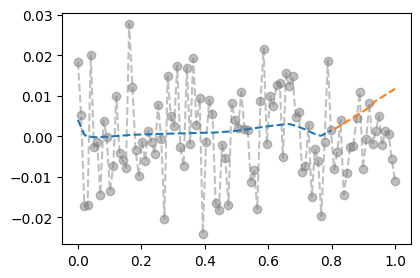

In [ ]:
plt.plot(x_all,y_all,'--o',alpha=0.5,color="gray")
plt.plot(x,net(x).data,'--')
plt.plot(xx,net(xx).data,'--')

## B. 드랍아웃 레이어 

`-` 드랍아웃의 성질1: 드랍아웃의 계산방식을 이해해보자. 

In [ ]:
u = torch.randn(10,2)
d = torch.nn.Dropout(0.9)
u

tensor([[ 0.2325, -0.2137],
        [-1.1099,  0.1651],
        [-0.6292, -0.6375],
        [-0.7331, -0.4100],
        [ 0.3024,  0.1195],
        [ 1.6408,  0.9799],
        [ 0.6248, -0.6950],
        [-0.4911, -1.5387],
        [ 0.3758,  0.2701],
        [ 1.5462, -0.1872]])

In [ ]:
d(u)

tensor([[ 0.0000, -0.0000],
        [-0.0000,  0.0000],
        [-6.2916, -0.0000],
        [-7.3306, -4.0995],
        [ 0.0000,  0.0000],
        [ 0.0000,  0.0000],
        [ 0.0000, -0.0000],
        [-0.0000, -0.0000],
        [ 0.0000,  0.0000],
        [ 0.0000, -0.0000]])

- 90\%의 드랍아웃: 드랍아웃층의 입력 중 임의로 90\%를 골라서 결과를 0으로 만든다. + 그리고 0이 되지않고 살아남은 값들은 10배 만큼 값이 커진다.
- 남은값을 10배 키우는 이유? 출력의 평균값을 보정하기 위해서

`-` 드랍아웃의 성질2: 드랍아웃을 on/off 하는 방법을 이해해보자. 

In [ ]:
u = torch.randn(10,2)
u

tensor([[ 1.5448,  0.6084],
        [-0.2335, -0.0364],
        [ 0.2034,  1.2170],
        [-0.3361,  0.2241],
        [ 1.7618,  0.2731],
        [-0.5324, -1.4465],
        [-1.0775,  1.2933],
        [ 0.8029, -1.0636],
        [-0.6346, -0.7101],
        [ 0.9358, -0.2241]])

In [ ]:
net = torch.nn.Sequential(
    torch.nn.Dropout(0.9)
)
net

Sequential(
  (0): Dropout(p=0.9, inplace=False)
)

In [ ]:
u,net(u)

(tensor([[ 1.5448,  0.6084],
         [-0.2335, -0.0364],
         [ 0.2034,  1.2170],
         [-0.3361,  0.2241],
         [ 1.7618,  0.2731],
         [-0.5324, -1.4465],
         [-1.0775,  1.2933],
         [ 0.8029, -1.0636],
         [-0.6346, -0.7101],
         [ 0.9358, -0.2241]]),
 tensor([[0.0000, 0.0000],
         [-0.0000, -0.0000],
         [0.0000, 0.0000],
         [-0.0000, 0.0000],
         [0.0000, 0.0000],
         [-0.0000, -0.0000],
         [-0.0000, 0.0000],
         [0.0000, -0.0000],
         [-0.0000, -0.0000],
         [9.3584, -0.0000]]))

In [ ]:
net.training

True

In [ ]:
net.eval() # 드랍아웃이 무력화

Sequential(
  (0): Dropout(p=0.9, inplace=False)
)

In [ ]:
u,net(u)

(tensor([[ 1.5448,  0.6084],
         [-0.2335, -0.0364],
         [ 0.2034,  1.2170],
         [-0.3361,  0.2241],
         [ 1.7618,  0.2731],
         [-0.5324, -1.4465],
         [-1.0775,  1.2933],
         [ 0.8029, -1.0636],
         [-0.6346, -0.7101],
         [ 0.9358, -0.2241]]),
 tensor([[ 1.5448,  0.6084],
         [-0.2335, -0.0364],
         [ 0.2034,  1.2170],
         [-0.3361,  0.2241],
         [ 1.7618,  0.2731],
         [-0.5324, -1.4465],
         [-1.0775,  1.2933],
         [ 0.8029, -1.0636],
         [-0.6346, -0.7101],
         [ 0.9358, -0.2241]]))

`-` 드랍아웃레이어 정리 

- 계산: (1) 입력의 일부를 임의로 0으로 만드는 역할 (2) 0이 안된것들은 스칼라배하여 드랍아웃을 통과한 모든 숫자들의 총합이 대체로 일정하게 되도록 조정
- on/off: 학습시에는 dropout on / 학습을 하지 않을 경우는 dropout off
- 느낌: 일부러 패널티를 안고 학습하는 느낌.. 
- 효과: 오버피팅을 억제하는 효과가 있음

> 참고: 오버피팅을 잡는 방법은 드랍아웃만 있는게 아니다.. 

## C. 드랍아웃 레이어의 위치 

`-` ReLU,dropout의 특이한 성질: $\text{dropout}(\text{relu}({\bf x}))=\text{relu}(\text{dropout}({\bf x}))$  

In [ ]:
u = torch.randn(10,2)
r = torch.nn.ReLU()
d = torch.nn.Dropout()

In [ ]:
torch.manual_seed(0)
d(r(u))

tensor([[2.8004, 0.0000],
        [0.0000, 1.4576],
        [4.3925, 0.0000],
        [0.0000, 1.4472],
        [0.0000, 2.3459],
        [0.0000, 0.0000],
        [0.0000, 0.4245],
        [0.0000, 1.8586],
        [0.0000, 0.1394],
        [0.0000, 0.0000]])

In [ ]:
torch.manual_seed(0)
r(d(u))

tensor([[2.8004, 0.0000],
        [-0.0000, 1.4576],
        [4.3925, -0.0000],
        [-0.0000, 1.4472],
        [0.0000, 2.3459],
        [0.0000, 0.0000],
        [0.0000, 0.4245],
        [0.0000, 1.8586],
        [-0.0000, 0.1394],
        [-0.0000, 0.0000]])

`-` 다른 활성화함수는 성립안함 

In [ ]:
u = torch.randn(10,2)
s = torch.nn.Sigmoid()
d = torch.nn.Dropout()

In [ ]:
torch.manual_seed(0)
d(s(u))

tensor([[0.4801, 0.0000],
        [0.0000, 1.4006],
        [0.3487, 0.0000],
        [0.0000, 1.2299],
        [0.9213, 1.6180],
        [1.1322, 0.0000],
        [0.0000, 1.4407],
        [0.6015, 1.4349],
        [0.0000, 1.7626],
        [0.0000, 0.0000]])

In [ ]:
torch.manual_seed(0)
s(d(u))

tensor([[0.0907, 0.5000],
        [0.5000, 0.8452],
        [0.0427, 0.5000],
        [0.5000, 0.7183],
        [0.4218, 0.9472],
        [0.6300, 0.5000],
        [0.5000, 0.8691],
        [0.1561, 0.8657],
        [0.5000, 0.9822],
        [0.5000, 0.5000]])

`-` 결론: 드랍아웃은 활성화 함수 바로 뒤에 오는게 맞음. (그렇지 않다면 0을 만들 수 없는걸?) 그렇지만 ReLU의 경우 활성화 함수 직전에 취하기도 함. 

## D. 평균보정의 필요성


`-` 90%의 드랍아웃에서 출력결과에 왜 x10하는지 좀 더 자세히 설명하여 보자. 

`-` 아래의 데이터를 관찰하자. 

In [ ]:
x,_ = torch.randn(300).sort()
y = relu(20*x) + torch.randn(300)
x,y = x.reshape(-1,1), y.reshape(-1,1)

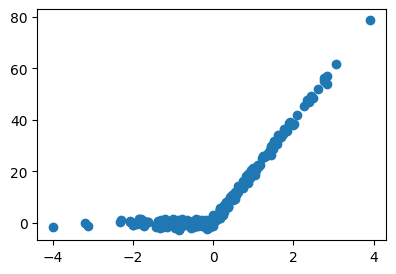

In [ ]:
plt.plot(x,y,'o')

`-` 적합해보자.

In [ ]:
torch.manual_seed(43052)
net = torch.nn.Sequential(
    torch.nn.Linear(1,1000),
    torch.nn.ReLU(),
    torch.nn.Dropout(0.1),
    torch.nn.Linear(1000,1,bias=False),
)
loss_fn = torch.nn.MSELoss()
optimizr = torch.optim.Adam(net.parameters())
#---#
for epoc in range(5000):
    ## 1 
    yhat = net(x)
    ## 2 
    loss = loss_fn(yhat,y)
    ## 3 
    loss.backward()
    ## 4 
    optimizr.step()
    optimizr.zero_grad()

In [ ]:
net.eval()

Sequential(
  (0): Linear(in_features=1, out_features=1000, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.1, inplace=False)
  (3): Linear(in_features=1000, out_features=1, bias=False)
)

In [ ]:
net.training

False

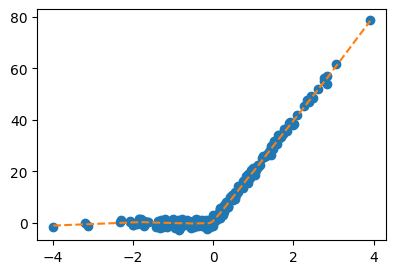

In [ ]:
plt.plot(x,y,'o')
plt.plot(x,net(x).data,'--')

`-` 주황색선이나오는 이유 설명해보자. 

In [ ]:
U = net[:-1](x).data 
W = net[-1].weight.T 

*아래3개는 동일한코드임*

In [ ]:
net(x).reshape(-1)[:10] # 코드1

tensor([-0.9858, -0.5127, -0.4687,  0.0514,  0.0558,  0.2089,  0.2213,  0.2619,
         0.2691,  0.2823], grad_fn=<SliceBackward0>)

In [ ]:
(U@W).reshape(-1)[:10] # 코드2

tensor([-0.9858, -0.5127, -0.4687,  0.0514,  0.0558,  0.2089,  0.2213,  0.2619,
         0.2691,  0.2823], grad_fn=<SliceBackward0>)

In [ ]:
((U*W.reshape(-1)).sum(axis=1))[:10] # 코드3

tensor([-0.9858, -0.5127, -0.4687,  0.0514,  0.0558,  0.2089,  0.2213,  0.2619,
         0.2691,  0.2823], grad_fn=<SliceBackward0>)

*따라서 아래의 주황색선들의 `.sum(axis=1)` 하기만 하면 `net(x)`의 결과가 된다.*

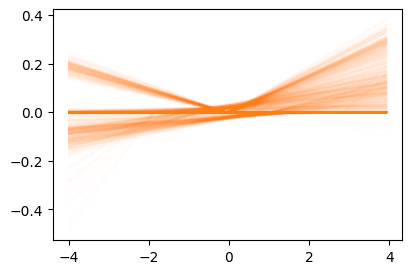

In [ ]:
plt.plot(x,U*W.reshape(-1).data,color="C1",alpha=0.02);

`-` 즉 왼쪽의 주황색선^[1000개가 있음]이 모두 합쳐져서 오른쪽의 점선이된다. 

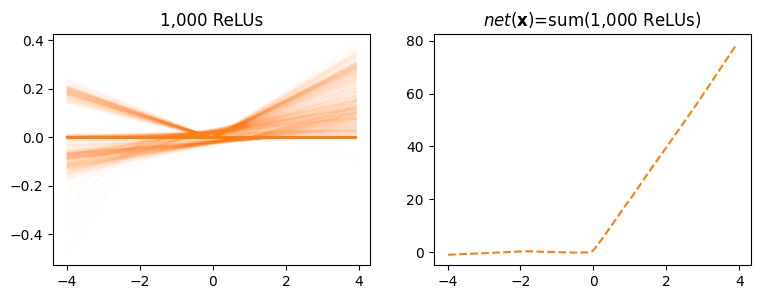

In [ ]:
fig,ax = plt.subplots(1,2,figsize=(9,3))
ax[0].plot(x,U*W.reshape(-1).data,color="C1",alpha=0.02);
ax[0].set_title("1,000 ReLUs")
ax[1].plot(x,net(x).data,'--',color="C1")
ax[1].set_title(r"$net({\bf x})$=sum(1,000 ReLUs)");

- 만약에 왼쪽의 주황색선이 10%만 사용되어서 100개의 렐루만 사용되었다면? 대충 x10을 해줘야 `net(x)` 가 나오지 않겠어요? 

# 6. CPU vs GPU 

`-` 파이토치에서 GPU를 쓰는 방법을 알아보자. (사실 지금까지 우리는 CPU만 쓰고 있었음) 

`-` 코랩에서 GPU설정하는 방법: (아래영상참고)

{{<video https://youtu.be/GyBL2YBCzoc >}}

## A. GPU 사용방법 

`-` cpu 연산이 가능한 메모리에 데이터 저장

In [ ]:
torch.manual_seed(43052)
x_cpu = torch.tensor([0.0,0.1,0.2]).reshape(-1,1) 
y_cpu = torch.tensor([0.0,0.2,0.4]).reshape(-1,1) 
net_cpu = torch.nn.Linear(1,1) 

`-` gpu 연산이 가능한 메모리에 데이터 저장 

In [ ]:
!nvidia-smi # before

Mon Apr  1 16:42:53 2024       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 535.161.07             Driver Version: 535.161.07   CUDA Version: 12.2     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  NVIDIA GeForce RTX 3090        Off | 00000000:09:00.0 Off |                  N/A |
|  0%   35C    P8              34W / 420W |     26MiB / 24576MiB |      0%      Default |
|                                         |                      |                  N/A |
+-----------------------------------------+----------------------+--

In [ ]:
torch.manual_seed(43052)
x_gpu = x_cpu.to("cuda:0")
y_gpu = y_cpu.to("cuda:0")
net_gpu = torch.nn.Linear(1,1).to("cuda:0") 

In [ ]:
!nvidia-smi

Mon Apr  1 16:42:53 2024       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 535.161.07             Driver Version: 535.161.07   CUDA Version: 12.2     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  NVIDIA GeForce RTX 3090        Off | 00000000:09:00.0 Off |                  N/A |
|  0%   37C    P2              39W / 420W |    287MiB / 24576MiB |      2%      Default |
|                                         |                      |                  N/A |
+-----------------------------------------+----------------------+--

> GPU에 메모리를 올리면 GPU메모리가 점유된다! (26MiB -> 287MiB) 

`-` cpu 혹은 gpu 연산이 가능한 메모리에 저장된 값들을 확인 

In [ ]:
x_cpu, y_cpu, net_cpu.weight, net_cpu.bias

(tensor([[0.0000],
         [0.1000],
         [0.2000]]),
 tensor([[0.0000],
         [0.2000],
         [0.4000]]),
 Parameter containing:
 tensor([[-0.3467]], requires_grad=True),
 Parameter containing:
 tensor([-0.8470], requires_grad=True))

In [ ]:
x_gpu, y_gpu, net_gpu.weight, net_gpu.bias

(tensor([[0.0000],
         [0.1000],
         [0.2000]], device='cuda:0'),
 tensor([[0.0000],
         [0.2000],
         [0.4000]], device='cuda:0'),
 Parameter containing:
 tensor([[-0.3467]], device='cuda:0', requires_grad=True),
 Parameter containing:
 tensor([-0.8470], device='cuda:0', requires_grad=True))

`-` gpu는 gpu끼리 연산가능하고 cpu는 cpu끼리 연산가능함 

(예시1)

In [ ]:
net_cpu(x_cpu) 

tensor([[-0.8470],
        [-0.8817],
        [-0.9164]], grad_fn=<AddmmBackward0>)

(예시2)

In [ ]:
net_gpu(x_gpu) 

tensor([[-0.8470],
        [-0.8817],
        [-0.9164]], device='cuda:0', grad_fn=<AddmmBackward0>)

(예시3)

In [ ]:
net_cpu(x_gpu) 

RuntimeError: Expected all tensors to be on the same device, but found at least two devices, cpu and cuda:0! (when checking argument for argument mat1 in method wrapper_CUDA_addmm)

::: {.callout-note}
#### 강의중 net을 재선언한 이유

`-` 아래와 같이 `x_cpu` 혹은 `y_cpu`에 `.to("cuda:0")`메소드를 쓸 경우 

```Python
x_cpu.to("cuda:0")
y_cpu.to("cuda:0")
```

`x_cpu`와 `y_cpu`는 cpu에 그대로 있음. 

`-` 그런데 아래와 같이 `net_cpu`에서 `.to("cuda:0")`메소드를 쓸 경우 

```Python
net_cpu.to("cuda:0")
```

`net_cpu` 자체가 gpu에 올라가게 됨. 
:::

(예시4)

In [ ]:
net_gpu(x_cpu)

RuntimeError: Expected all tensors to be on the same device, but found at least two devices, cuda:0 and cpu! (when checking argument for argument mat1 in method wrapper_CUDA_addmm)

(예시5)

In [ ]:
torch.mean((y_cpu-net_cpu(x_cpu))**2)

tensor(1.2068, grad_fn=<MeanBackward0>)

(예시6)

In [ ]:
torch.mean((y_gpu-net_gpu(x_gpu))**2)

tensor(1.2068, device='cuda:0', grad_fn=<MeanBackward0>)

(예시7)

In [ ]:
torch.mean((y_gpu-net_cpu(x_cpu))**2)

RuntimeError: Expected all tensors to be on the same device, but found at least two devices, cuda:0 and cpu!

(예시8)

In [ ]:
torch.mean((y_cpu-net_gpu(x_gpu))**2)

RuntimeError: Expected all tensors to be on the same device, but found at least two devices, cuda:0 and cpu!

## B. 시간측정 (예비학습) 

In [ ]:
import time 

In [ ]:
t1 = time.time()

In [ ]:
t2 = time.time()

In [ ]:
t2-t1

1.2487025260925293

## C. CPU vs GPU (512 nodes)

`-` CPU (512 nodes) 

In [ ]:
torch.manual_seed(5) 
x=torch.linspace(0,1,100).reshape(-1,1)
y=torch.randn(100).reshape(-1,1)*0.01
#---#
net = torch.nn.Sequential(
    torch.nn.Linear(1,512),
    torch.nn.ReLU(),
    torch.nn.Linear(512,1)
)
loss_fn = torch.nn.MSELoss()
optimizr = torch.optim.Adam(net.parameters())
#---#
t1 = time.time()
for epoc in range(1000):
    # 1 
    yhat = net(x)
    # 2 
    loss = loss_fn(yhat,y)
    # 3 
    loss.backward()
    # 4 
    optimizr.step()
    optimizr.zero_grad()
t2 = time.time()
t2-t1

0.35651373863220215

`-` GPU (512 nodes) 

In [ ]:
torch.manual_seed(5) 
x=torch.linspace(0,1,100).reshape(-1,1).to("cuda:0")
y=(torch.randn(100).reshape(-1,1)*0.01).to("cuda:0")
#---#
net = torch.nn.Sequential(
    torch.nn.Linear(1,512),
    torch.nn.ReLU(),
    torch.nn.Linear(512,1)
).to("cuda:0")
loss_fn = torch.nn.MSELoss()
optimizr = torch.optim.Adam(net.parameters())
#---#
t1 = time.time()
for epoc in range(1000):
    # 1 
    yhat = net(x)
    # 2 
    loss = loss_fn(yhat,y)
    # 3 
    loss.backward()
    # 4 
    optimizr.step()
    optimizr.zero_grad()
t2 = time.time()
t2-t1

0.5209517478942871

- CPU가 더 빠르다??

## D. CPU vs GPU (20,480 nodes)

`-` CPU (20,480)

In [ ]:
torch.manual_seed(5) 
x=torch.linspace(0,1,100).reshape(-1,1)
y=torch.randn(100).reshape(-1,1)*0.01
#---#
net = torch.nn.Sequential(
    torch.nn.Linear(1,20480),
    torch.nn.ReLU(),
    torch.nn.Linear(20480,1)
)
loss_fn = torch.nn.MSELoss()
optimizr = torch.optim.Adam(net.parameters())
#---#
t1 = time.time()
for epoc in range(1000):
    # 1 
    yhat = net(x)
    # 2 
    loss = loss_fn(yhat,y)
    # 3 
    loss.backward()
    # 4 
    optimizr.step()
    optimizr.zero_grad()
t2 = time.time()
t2-t1

2.7291958332061768

`-` GPU (20,480)

In [ ]:
torch.manual_seed(5) 
x=torch.linspace(0,1,100).reshape(-1,1).to("cuda:0")
y=(torch.randn(100).reshape(-1,1)*0.01).to("cuda:0")
#---#
net = torch.nn.Sequential(
    torch.nn.Linear(1,20480),
    torch.nn.ReLU(),
    torch.nn.Linear(20480,1)
).to("cuda:0")
loss_fn = torch.nn.MSELoss()
optimizr = torch.optim.Adam(net.parameters())
#---#
t1 = time.time()
for epoc in range(1000):
    # 1 
    yhat = net(x)
    # 2 
    loss = loss_fn(yhat,y)
    # 3 
    loss.backward()
    # 4 
    optimizr.step()
    optimizr.zero_grad()
t2 = time.time()
t2-t1

0.4499187469482422

- 왜 이런 차이가 나는가? 
- 연산을 하는 주체는 코어인데 CPU는 수는 적지만 일을 잘하는 코어들을 가지고 있고 GPU는 일은 못하지만 다수의 코어를 가지고 있기 때문 

## E. CPU vs GPU (204,800 nodes)

`-` CPU (204,800)

In [ ]:
torch.manual_seed(5) 
x=torch.linspace(0,1,100).reshape(-1,1)
y=torch.randn(100).reshape(-1,1)*0.01
#---#
net = torch.nn.Sequential(
    torch.nn.Linear(1,204800),
    torch.nn.ReLU(),
    torch.nn.Linear(204800,1)
)
loss_fn = torch.nn.MSELoss()
optimizr = torch.optim.Adam(net.parameters())
#---#
t1 = time.time()
for epoc in range(1000):
    # 1 
    yhat = net(x)
    # 2 
    loss = loss_fn(yhat,y)
    # 3 
    loss.backward()
    # 4 
    optimizr.step()
    optimizr.zero_grad()
t2 = time.time()
t2-t1

85.68583369255066

`-` GPU (204,800)

In [ ]:
torch.manual_seed(5) 
x=torch.linspace(0,1,100).reshape(-1,1).to("cuda:0")
y=(torch.randn(100).reshape(-1,1)*0.01).to("cuda:0")
#---#
net = torch.nn.Sequential(
    torch.nn.Linear(1,204800),
    torch.nn.ReLU(),
    torch.nn.Linear(204800,1)
).to("cuda:0")
loss_fn = torch.nn.MSELoss()
optimizr = torch.optim.Adam(net.parameters())
#---#
t1 = time.time()
for epoc in range(1000):
    # 1 
    yhat = net(x)
    # 2 
    loss = loss_fn(yhat,y)
    # 3 
    loss.backward()
    # 4 
    optimizr.step()
    optimizr.zero_grad()
t2 = time.time()
t2-t1

1.3954846858978271

# 7. "확률적" 경사하강법

## A. 의문: 좀 이상하지 않아요? 

`-` 국민상식: GPU 비싸요.. <https://bbs.ruliweb.com/community/board/300143/read/61066881>

- GPU 메모리 많아봐야 24GB, 그래도 비싸요.. <http://shop.danawa.com/virtualestimate/?controller=estimateMain&methods=index&marketPlaceSeq=16>
- GPU 메모리가 80GB일 경우 가격: <https://prod.danawa.com/info/?pcode=21458333>

`-` 우리가 분석하는 데이터: 빅데이터..?

In [ ]:
x = torch.linspace(-10,10,100000).reshape(-1,1)
eps = torch.randn(100000).reshape(-1,1)
y = x*2 + eps 

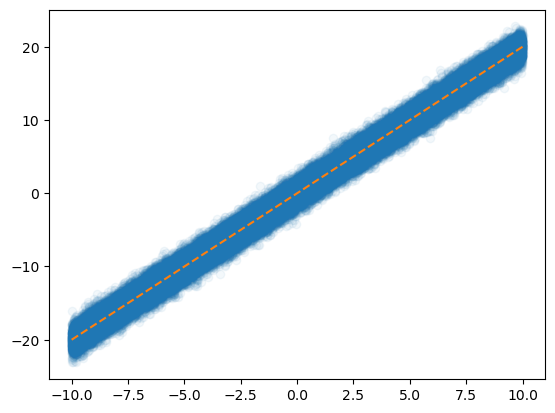

In [ ]:
plt.plot(x,y,'o',alpha=0.05)
plt.plot(x,2*x,'--')

`-` 데이터의 크기가 커지는 순간 `X.to("cuda:0")`, `y.to("cuda:0")` 쓰면 난리나겠는걸? 

`-` 데이터를 100개중에 1개만 꼴로만 쓰면 어떨까? 

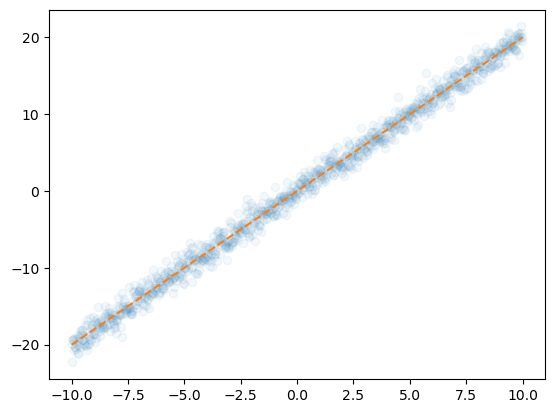

In [ ]:
plt.plot(x[::100],y[::100],'o',alpha=0.05)
plt.plot(x,2*x,'--')

- 대충 이거만 가지고 적합해도 충분히 정확할것 같은데?

## B. X,y 데이터를 굳이 모두 GPU에 넘겨야 하는가?

`-` 데이터셋을 짝홀로 나누어서 번갈아가면서 GPU에 올렸다 내렸다하면 안되나? 

`-` 아래의 알고리즘을 생각해보자. 

1. 데이터를 반으로 나눈다. 
2. 짝수obs의 x,y 그리고 net의 모든 파라메터를 GPU에 올린다. 
3. yhat, loss, grad, update 수행
4. 짝수obs의 x,y를 GPU메모리에서 내린다. 그리고 홀수obs의 x,y를 GPU메모리에 올린다. 
5. yhat, loss, grad, update 수행 
6. 홀수obs의 x,y를 GPU메모리에서 내린다. 그리고 짝수obs의 x,y를 GPU메모리에 올린다. 
7. 반복 

> 이러면 되는거아니야???? ---> 맞아요

## C. 경사하강법, 확률적경사하강법, 미니배치 경사하강법 

10개의 샘플이 있다고 가정. $\{(x_i,y_i)\}_{i=1}^{10}$

`# ver1` --  모든 샘플을 이용하여 slope 계산

(epoch 1) $loss=\sum_{i=1}^{10}(y_i-w_0-w_1x_i)^2 \to slope  \to update$

(epoch 2) $loss=\sum_{i=1}^{10}(y_i-w_0-w_1x_i)^2 \to slope  \to update$

...

> 우리가 항상 이렇게 했죠!

`# ver2` -- 하나의 샘플만을 이용하여 slope 계산

(epoch 1) 

- $loss=(y_1-w_0-w_1x_1)^2 \to slope \to update$
- $loss=(y_2-w_0-w_1x_2)^2 \to slope \to update$
- ...
- $loss=(y_{10}-w_0-w_1x_{10})^2  \to  slope  \to  update$

(epoch 2) 

- $loss=(y_1-w_0-w_1x_1)^2  \to slope  \to  update$
- $loss=(y_2-w_0-w_1x_2)^2  \to slope  \to  update$
- ...
- $loss=(y_{10}-w_0-w_1x_{10})^2  \to  slope  \to  update$

...

`# ver3` -- $m (\leq n)$ 개의 샘플을 이용하여 slope 계산

$m=3$이라고 하자. 

(epoch 1) 

- $loss=\sum_{i=1}^{3}(y_i-w_0-w_1x_i)^2  \to  slope  \to  update$
- $loss=\sum_{i=4}^{6}(y_i-w_0-w_1x_i)^2  \to  slope  \to  update$
- $loss=\sum_{i=7}^{9}(y_i-w_0-w_1x_i)^2  \to  slope  \to  update$
- $loss=(y_{10}-w_0-w_1x_{10})^2  \to  slope  \to  update$

(epoch 2) 

- $loss=\sum_{i=1}^{3}(y_i-w_0-w_1x_i)^2  \to  slope  \to  update$
- $loss=\sum_{i=4}^{6}(y_i-w_0-w_1x_i)^2  \to  slope  \to  update$
- $loss=\sum_{i=7}^{9}(y_i-w_0-w_1x_i)^2  \to  slope  \to  update$
- $loss=(y_{10}-w_0-w_1x_{10})^2  \to  slope  \to  update$

...

## D. 용어의 정리 

**옛날**

`-` ver1: gradient descent, batch gradient descent

`-` ver2: stochastic gradient descent

`-` ver3: mini-batch gradient descent, mini-batch stochastic gradient descent

**요즘**

`-` ver1: gradient descent

`-` ver2: stochastic gradient descent with batch size = 1

`-` **ver3: stochastic gradient descent**
- https://www.deeplearningbook.org/contents/optimization.html, 알고리즘 8-1 참고.

## E. Dataset(`ds`), DataLoader(`dl`)

> 취지는 알겠으나, C의 과정을 실제 구현하려면 진짜 힘들것 같아요.. (입코딩과 손코딩의 차이) --> 이걸 해결하기 위해서 파이토치에서는 DataLoader라는 오브젝트를 준비했음!

`-` ds: 섭스크립터블함

In [ ]:
x=torch.tensor(range(10)).float().reshape(-1,1)
y=torch.tensor([1.0]*5+[0.0]*5).reshape(-1,1)
torch.concat([x,y],axis=1)

tensor([[0., 1.],
        [1., 1.],
        [2., 1.],
        [3., 1.],
        [4., 1.],
        [5., 0.],
        [6., 0.],
        [7., 0.],
        [8., 0.],
        [9., 0.]])

In [ ]:
ds=torch.utils.data.TensorDataset(x,y)
ds

In [ ]:
ds.tensors 
# 생긴건 ds.tensors = (x,y) 임

(tensor([[0.],
         [1.],
         [2.],
         [3.],
         [4.],
         [5.],
         [6.],
         [7.],
         [8.],
         [9.]]),
 tensor([[1.],
         [1.],
         [1.],
         [1.],
         [1.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.]]))

In [ ]:
ds[0],(x,y)[0] # (x,y) 튜플자체는 아님.. 인덱싱이 다르게 동작

((tensor([0.]), tensor([1.])),
 tensor([[0.],
         [1.],
         [2.],
         [3.],
         [4.],
         [5.],
         [6.],
         [7.],
         [8.],
         [9.]]))

::: {.callout-note}
여기서 제가 `__iter__` 가 숨겨져 있는 오브젝트일 경우만 `for`문이 동작한다고 설명 했는데요, `__getitem__`이 있는 경우도 동작한다고 합니다. **제가 잘못 알고 있었어요. 혼란을 드려 죄송합니다**. 

- 그래도 `dl`은 for 를 돌리기위해서 만든 오브젝트라는 설명은 맞는 설명입니다. 
- `ds`역시 독특한 방식의 인덱싱을 지원하도록 한 오브젝트라는 설명도 맞는 설명입니다. 
:::

`-` dl: 섭스크립터블하지 않지만 이터러블함 

In [ ]:
dl=torch.utils.data.DataLoader(ds,batch_size=3)
#set(dir(dl)) & {'__iter__'}

In [ ]:
for xi,yi in dl:
    print(f"x_batch:{xi.tolist()} \t y_batch:{yi.tolist()}")

x_batch:[[0.0], [1.0], [2.0]] 	 y_batch:[[1.0], [1.0], [1.0]]
x_batch:[[3.0], [4.0], [5.0]] 	 y_batch:[[1.0], [1.0], [0.0]]
x_batch:[[6.0], [7.0], [8.0]] 	 y_batch:[[0.0], [0.0], [0.0]]
x_batch:[[9.0]] 	 y_batch:[[0.0]]


`-` 마지막관측치는 뭔데 단독으로 업데이트하냐?? --> shuffle True 같이 자잘한 옵션도 있음.. 

In [ ]:
dl = torch.utils.data.DataLoader(ds,batch_size=3,shuffle=True)
for xi,yi in dl:
    print(f'x_batch={xi.tolist()} \t y_batch={yi.tolist()}')

x_batch=[[1.0], [8.0], [0.0]] 	 y_batch=[[1.0], [0.0], [1.0]]
x_batch=[[2.0], [7.0], [6.0]] 	 y_batch=[[1.0], [0.0], [0.0]]
x_batch=[[5.0], [3.0], [9.0]] 	 y_batch=[[0.0], [1.0], [0.0]]
x_batch=[[4.0]] 	 y_batch=[[1.0]]


## F. ds, dl을 이용한 MNIST 구현

`-` 목표: 확률적경사하강법과 그냥 경사하강법의 성능을 "동일 반복횟수"로 비교해보자.

- batch_size = 2048로 설정할것 

`-` 그냥 경사하강법 -- 미니배치 안쓰는 학습, 우리가 맨날하는 그거

In [ ]:
## Step1: 데이터준비 
path = fastai.data.external.untar_data('https://s3.amazonaws.com/fast-ai-imageclas/mnist_png.tgz')
X0 = torch.stack([torchvision.io.read_image(str(fname)) for fname in (path/'training/0').ls()])
X1 = torch.stack([torchvision.io.read_image(str(fname)) for fname in (path/'training/1').ls()])
X = torch.concat([X0,X1],axis=0).reshape(-1,1*28*28)/255
y = torch.tensor([0.0]*len(X0) + [1.0]*len(X1)).reshape(-1,1)
## Step2: 학습가능한 오브젝트 생성
torch.manual_seed(1)
net = torch.nn.Sequential(
    torch.nn.Linear(784,32),
    torch.nn.ReLU(),
    torch.nn.Linear(32,1),
    torch.nn.Sigmoid()
)
loss_fn = torch.nn.BCELoss()
optimizr = torch.optim.SGD(net.parameters())
## Step3: fit  
for epoc in range(700):
    # step1 
    yhat = net(X)
    # step2 
    loss = loss_fn(yhat,y)
    # step3     
    loss.backward()
    # step4 
    optimizr.step()
    optimizr.zero_grad()
## Step4: Predict 
((yhat > 0.5)*1.0 ==  y).float().mean()

tensor(0.9953)

`-` "확률적"경사하강법 -- 미니배치 쓰는 학습 

In [ ]:
## Step1: 데이터준비 
path = fastai.data.external.untar_data('https://s3.amazonaws.com/fast-ai-imageclas/mnist_png.tgz')
X0 = torch.stack([torchvision.io.read_image(str(fname)) for fname in (path/'training/0').ls()])
X1 = torch.stack([torchvision.io.read_image(str(fname)) for fname in (path/'training/1').ls()])
X = torch.concat([X0,X1],axis=0).reshape(-1,1*28*28)/255
y = torch.tensor([0.0]*len(X0) + [1.0]*len(X1)).reshape(-1,1)
ds = torch.utils.data.TensorDataset(X,y)
dl = torch.utils.data.DataLoader(ds,batch_size=2048)
## Step2: 학습가능한 오브젝트 생성
torch.manual_seed(1)
net = torch.nn.Sequential(
    torch.nn.Linear(784,32),
    torch.nn.ReLU(),
    torch.nn.Linear(32,1),
    torch.nn.Sigmoid()
)
loss_fn = torch.nn.BCELoss()
optimizr = torch.optim.SGD(net.parameters())
# ## Step3: fit  
for epoc in range(100):
    for xi,yi in dl:        
        # step1 
        #yihat = net(xi)
        # step2 
        loss = loss_fn(net(xi),yi)
        # step3     
        loss.backward()
        # step4 
        optimizr.step()
        optimizr.zero_grad()
# ## Step4: Predict 
((net(X) > 0.5)*1.0 ==  y).float().mean()

tensor(0.9931)

`-` GPU를 활용하는 "확률적"경사하강법 -- 실제적으로는 이게 최종알고리즘 

In [ ]:
## Step1: 데이터준비 
path = fastai.data.external.untar_data('https://s3.amazonaws.com/fast-ai-imageclas/mnist_png.tgz')
X0 = torch.stack([torchvision.io.read_image(str(fname)) for fname in (path/'training/0').ls()])
X1 = torch.stack([torchvision.io.read_image(str(fname)) for fname in (path/'training/1').ls()])
X = torch.concat([X0,X1],axis=0).reshape(-1,1*28*28)/255
y = torch.tensor([0.0]*len(X0) + [1.0]*len(X1)).reshape(-1,1)
ds = torch.utils.data.TensorDataset(X,y)
dl = torch.utils.data.DataLoader(ds,batch_size=2048)
## Step2: 학습가능한 오브젝트 생성
torch.manual_seed(1)
net = torch.nn.Sequential(
    torch.nn.Linear(784,32),
    torch.nn.ReLU(),
    torch.nn.Linear(32,1),
    torch.nn.Sigmoid()
).to("cuda:0")
loss_fn = torch.nn.BCELoss()
optimizr = torch.optim.SGD(net.parameters())
## Step3: fit  
for epoc in range(100):
    for xi,yi in dl:        
        # step1 
        # step2 
        loss = loss_fn(net(xi.to("cuda:0")),yi.to("cuda:0"))
        # step3     
        loss.backward()
        # step4 
        optimizr.step()
        optimizr.zero_grad()
# ## Step4: Predict
net.to("cpu")
((net(X) > 0.5)*1.0 ==  y).float().mean()

tensor(0.9931)

---

# 1. 다중클래스 분류

## A. 결론 (그냥 외우세요)

`-` 2개의 class를 구분하는 문제가 아니라 $k$개의 class를 구분해야 한다면? 

***일반적인 개념*** 

- 손실함수: BCE loss $\to$ Cross Entropy loss 
- 마지막층의 선형변환: torch.nn.Linear(?,1) $\to$ torch.nn.Linear(?,k) 
- **마지막층의 활성화: sig $\to$ softmax**

***파이토치 한정*** 

- **y의형태: (n,) vector + int형 // (n,k) one-hot encoded matrix + float형**
- 손실함수: torch.nn.BCEWithLogitsLoss,  $\to$ torch.nn.CrossEntropyLoss
- 마지막층의 선형변환: torch.nn.Linear(?,1) $\to$ torch.nn.Linear(?,k) 
- **마지막층의 활성화: None $\to$ None (손실함수에 이미 마지막층의 활성화가 포함)**

## B. 실습: 3개의 클래스를 구분 

`-` 정리된 코드1: 통계잘하는데 파이토치 못쓰는 사람의 코드 

In [ ]:
## Step1: 데이터준비 
path = fastai.data.external.untar_data('https://s3.amazonaws.com/fast-ai-imageclas/mnist_png.tgz')
X0 = torch.stack([torchvision.io.read_image(str(fname)) for fname in (path/'training/0').ls()])
X1 = torch.stack([torchvision.io.read_image(str(fname)) for fname in (path/'training/1').ls()])
X2 = torch.stack([torchvision.io.read_image(str(fname)) for fname in (path/'training/2').ls()])
X = torch.concat([X0,X1,X2]).reshape(-1,1*28*28)/255
y = torch.nn.functional.one_hot(torch.tensor([0]*len(X0) + [1]*len(X1)+ [2]*len(X2))).float()
## Step2: 학습가능한 오브젝트 생성
torch.manual_seed(43052)
net = torch.nn.Sequential(
    torch.nn.Linear(784,32),
    torch.nn.ReLU(),
    torch.nn.Linear(32,3),
#    torch.nn.Softmax()
)
loss_fn = torch.nn.CrossEntropyLoss()
optimizr = torch.optim.Adam(net.parameters())
## Step3: 적합 
for epoc in range(100):
    ## step1 
    netout = net(X)
    ## step2 
    loss = loss_fn(netout,y)
    ## step3 
    loss.backward()
    ## step4 
    optimizr.step()
    optimizr.zero_grad()
    
## Step4: 적합 (혹은 적합결과확인)
(netout.argmax(axis=1) == y.argmax(axis=1)).float().mean()

tensor(0.9827)

`-` 정리된 코드2: 파이토치를 잘하는 사람의 코드 

In [ ]:
## Step1: 데이터준비 
path = fastai.data.external.untar_data('https://s3.amazonaws.com/fast-ai-imageclas/mnist_png.tgz')
X0 = torch.stack([torchvision.io.read_image(str(fname)) for fname in (path/'training/0').ls()])
X1 = torch.stack([torchvision.io.read_image(str(fname)) for fname in (path/'training/1').ls()])
X2 = torch.stack([torchvision.io.read_image(str(fname)) for fname in (path/'training/2').ls()])
X = torch.concat([X0,X1,X2]).reshape(-1,1*28*28)/255
#y = torch.nn.functional.one_hot(torch.tensor([0]*len(X0) + [1]*len(X1)+ [2]*len(X2))).float()
y = torch.tensor([0]*len(X0) + [1]*len(X1)+ [2]*len(X2))
## Step2: 학습가능한 오브젝트 생성
torch.manual_seed(43052)
net = torch.nn.Sequential(
    torch.nn.Linear(784,32),
    torch.nn.ReLU(),
    torch.nn.Linear(32,3),
#    torch.nn.Softmax()
)
loss_fn = torch.nn.CrossEntropyLoss()
optimizr = torch.optim.Adam(net.parameters())
## Step3: 적합 
for epoc in range(100):
    ## step1 
    netout = net(X)
    ## step2 
    loss = loss_fn(netout,y)
    ## step3 
    loss.backward()
    ## step4 
    optimizr.step()
    optimizr.zero_grad()
## Step4: 적합 (혹은 적합결과확인)    
(netout.argmax(axis=1) == y).float().mean()

tensor(0.9827)

- 완전같은코드임 

## C. Softmax 

`-` 눈치: softmax를 쓰기 직전의 숫자들은 (n,k)꼴로 되어있음. 각 observation 마다 k개의 숫자가 있는데, 그중에서 유난히 큰 하나의 숫자가 있음. 

In [ ]:
net(X)

tensor([[ 4.4836, -4.5924, -3.4632],
        [ 1.9839, -3.4456,  0.3030],
        [ 5.9082, -7.5250, -0.7634],
        ...,
        [-0.8089, -0.8294,  0.6012],
        [-2.1901, -0.4458,  0.7465],
        [-1.6856, -2.2825,  5.1892]], grad_fn=<AddmmBackward0>)

In [ ]:
y

tensor([0, 0, 0,  ..., 2, 2, 2])

`-` 수식 

- $\text{sig}(u)=\frac{e^u}{1+e^u}$
- $\text{softmax}({\boldsymbol u})=\text{softmax}([u_1,u_2,\dots,u_k])=\big[ \frac{e^{u_1}}{e^{u_1}+\dots e^{u_k}},\dots,\frac{e^{u_k}}{e^{u_1}+\dots e^{u_k}}\big]$

`-` torch.nn.Softmax() 손계산 

(예시1) -- 잘못계산 

In [ ]:
softmax = torch.nn.Softmax(dim=0)

In [ ]:
netout = torch.tensor([[-2.0,-2.0,0.0],
                        [3.14,3.14,3.14],
                        [0.0,0.0,2.0],
                        [2.0,2.0,4.0],
                        [0.0,0.0,0.0]])
netout

tensor([[-2.0000, -2.0000,  0.0000],
        [ 3.1400,  3.1400,  3.1400],
        [ 0.0000,  0.0000,  2.0000],
        [ 2.0000,  2.0000,  4.0000],
        [ 0.0000,  0.0000,  0.0000]])

In [ ]:
softmax(netout) 

tensor([[0.0041, 0.0041, 0.0115],
        [0.7081, 0.7081, 0.2653],
        [0.0306, 0.0306, 0.0848],
        [0.2265, 0.2265, 0.6269],
        [0.0306, 0.0306, 0.0115]])

(예시2) -- 이게 맞게 계산되는 것임 

In [ ]:
softmax = torch.nn.Softmax(dim=1)

In [ ]:
netout

tensor([[-2.0000, -2.0000,  0.0000],
        [ 3.1400,  3.1400,  3.1400],
        [ 0.0000,  0.0000,  2.0000],
        [ 2.0000,  2.0000,  4.0000],
        [ 0.0000,  0.0000,  0.0000]])

In [ ]:
softmax(netout)

tensor([[0.1065, 0.1065, 0.7870],
        [0.3333, 0.3333, 0.3333],
        [0.1065, 0.1065, 0.7870],
        [0.1065, 0.1065, 0.7870],
        [0.3333, 0.3333, 0.3333]])

(예시3) -- 차원을 명시안하면 맞게 계산해주고 경고 줌 

In [ ]:
softmax = torch.nn.Softmax()

In [ ]:
netout

tensor([[-2.0000, -2.0000,  0.0000],
        [ 3.1400,  3.1400,  3.1400],
        [ 0.0000,  0.0000,  2.0000],
        [ 2.0000,  2.0000,  4.0000],
        [ 0.0000,  0.0000,  0.0000]])

In [ ]:
softmax(netout)

/home/cgb3/anaconda3/envs/dl2024/lib/python3.11/site-packages/torch/nn/modules/module.py:1511: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


tensor([[0.1065, 0.1065, 0.7870],
        [0.3333, 0.3333, 0.3333],
        [0.1065, 0.1065, 0.7870],
        [0.1065, 0.1065, 0.7870],
        [0.3333, 0.3333, 0.3333]])

(예시4) -- 진짜 손계산 

In [ ]:
netout 

tensor([[-2.0000, -2.0000,  0.0000],
        [ 3.1400,  3.1400,  3.1400],
        [ 0.0000,  0.0000,  2.0000],
        [ 2.0000,  2.0000,  4.0000],
        [ 0.0000,  0.0000,  0.0000]])

In [ ]:
torch.exp(netout)

tensor([[ 0.1353,  0.1353,  1.0000],
        [23.1039, 23.1039, 23.1039],
        [ 1.0000,  1.0000,  7.3891],
        [ 7.3891,  7.3891, 54.5981],
        [ 1.0000,  1.0000,  1.0000]])

In [ ]:
0.1353/(0.1353 + 0.1353 + 1.0000), 0.1353/(0.1353 + 0.1353 + 1.0000), 1.0000/(0.1353 + 0.1353 + 1.0000) # 첫 obs

(0.10648512513773022, 0.10648512513773022, 0.7870297497245397)

In [ ]:
torch.exp(netout[1])/torch.exp(netout[1]).sum() # 두번째 obs 

tensor([0.3333, 0.3333, 0.3333])

## D. CrossEntropyLoss

`-` 수식 

***`# 2개의 카테고리`***

`-` 예제1: BCELoss vs BCEWithLogisticLoss

In [ ]:
y = torch.tensor([0,0,1]).reshape(-1,1).float()
netout = torch.tensor([-1, 0, 1]).reshape(-1,1).float()
y,netout

(tensor([[0.],
         [0.],
         [1.]]),
 tensor([[-1.],
         [ 0.],
         [ 1.]]))

In [ ]:
# 계산방법1: 공식암기
sig = torch.nn.Sigmoid()
yhat = sig(netout)
- torch.sum(torch.log(yhat)*y + torch.log(1-yhat)*(1-y))/3

tensor(0.4399)

In [ ]:
# 계산방법2: torch.nn.BCELoss() 이용
sig = torch.nn.Sigmoid()
yhat = sig(netout)
loss_fn = torch.nn.BCELoss()
loss_fn(yhat,y)

tensor(0.4399)

In [ ]:
# 계산방법3: torch.nn.BCEWithLogitsLoss() 이용
loss_fn = torch.nn.BCEWithLogitsLoss()
loss_fn(netout,y)

tensor(0.4399)

`-` 예제2: BCEWithLogisticLoss vs CrossEntropyLoss

In [ ]:
torch.concat([sig(netout),1-sig(netout)],axis=1)

tensor([[0.2689, 0.7311],
        [0.5000, 0.5000],
        [0.7311, 0.2689]])

In [ ]:
netout = torch.tensor([[3,2],[2,2],[5,6]]).float()
y = torch.tensor([[1,0],[1,0],[0,1]]).float()
y,netout #,netout[:,[1]]-netout[:,[0]]

(tensor([[1., 0.],
         [1., 0.],
         [0., 1.]]),
 tensor([[3., 2.],
         [2., 2.],
         [5., 6.]]))

In [ ]:
softmax(netout)

tensor([[0.7311, 0.2689],
        [0.5000, 0.5000],
        [0.2689, 0.7311]])

In [ ]:
# 계산방법1: 공식암기
-torch.sum(torch.log(softmax(netout))*y)/3

tensor(0.4399)

In [ ]:
# 계산방법2: torch.nn.CrossEntropyLoss() 이용 + y는 one-hot으로 정리
loss_fn = torch.nn.CrossEntropyLoss()
loss_fn(netout,y)

tensor(0.4399)

In [ ]:
# 계산방법3: torch.nn.CrossEntropyLoss() 이용 + y는 0,1 로 정리
loss_fn = torch.nn.CrossEntropyLoss()
loss_fn(netout,y)

tensor(0.4399)

`#`

***`# 3개의 카테고리`***

In [ ]:
y = torch.tensor([2,1,2,2,0])
y_onehot = torch.nn.functional.one_hot(y)
netout = torch.tensor(
    [[-2.0000, -2.0000,  0.0000],
     [ 3.1400,  3.1400,  3.1400],
     [ 0.0000,  0.0000,  2.0000],
     [ 2.0000,  2.0000,  4.0000],
     [ 0.0000,  0.0000,  0.0000]]
)
y,y_onehot

(tensor([2, 1, 2, 2, 0]),
 tensor([[0, 0, 1],
         [0, 1, 0],
         [0, 0, 1],
         [0, 0, 1],
         [1, 0, 0]]))

In [ ]:
## 방법1 -- 추천X
loss_fn = torch.nn.CrossEntropyLoss()
loss_fn(netout,y_onehot.float())

tensor(0.5832)

In [ ]:
## 방법2 -- 추천O
loss_fn = torch.nn.CrossEntropyLoss()
loss_fn(netout,y)

tensor(0.5832)

In [ ]:
## 방법3 -- 공식.. (이걸 쓰는사람은 없겠지?)
softmax = torch.nn.Softmax() 
loss_fn = torch.nn.CrossEntropyLoss()
- torch.sum(torch.log(softmax(netout))*y_onehot)/5

tensor(0.5832)

`#`

`-` 계산하는 공식을 아는것도 중요한데 torch.nn.CrossEntropyLoss() 에는 softmax 활성화함수가 이미 포함되어 있다는 것을 확인하는 것이 더 중요함. 

`-` torch.nn.CrossEntropyLoss() 는 사실 torch.nn.CEWithSoftmaxLoss() 정도로 바꾸는 것이 더 말이 되는 것 같다. 

## E. Minor Topic: 이진분류와 CrossEntropy

`-` 2개의 클래스일경우에도 CrossEntropy를 쓸 수 있지 않을까? 

In [ ]:
## Step1: 데이터준비 
path = fastai.data.external.untar_data(fastai.data.external.URLs.MNIST)
X0 = torch.stack([torchvision.io.read_image(str(fname)) for fname in (path/'training/0').ls()])
X1 = torch.stack([torchvision.io.read_image(str(fname)) for fname in (path/'training/1').ls()])
X = torch.concat([X0,X1]).reshape(-1,1*28*28)/255
y = torch.tensor([0]*len(X0) + [1]*len(X1))
## Step2: 학습가능한 오브젝트 생성
torch.manual_seed(43052)
net = torch.nn.Sequential(
    torch.nn.Linear(784,32),
    torch.nn.ReLU(),
    torch.nn.Linear(32,2),
    #torch.nn.Softmax()
)
loss_fn = torch.nn.CrossEntropyLoss()
optimizr = torch.optim.Adam(net.parameters())
## Step3: fit  
for epoc in range(70): 
    ## 1 
    ## 2 
    loss= loss_fn(net(X),y) 
    ## 3 
    loss.backward()
    ## 4 
    optimizr.step()
    optimizr.zero_grad() 
## Step4: Predict 
softmax = torch.nn.Softmax()
(net(X).argmax(axis=1) == y).float().mean()

tensor(0.9983)

`-` 이진분류문제 = "y=0 or y=1" 을 맞추는 문제 = 성공과 실패를 맞추는 문제 = 성공확률과 실패확률을 추정하는 문제 

`-` softmax, sigmoid

- softmax: (실패확률, 성공확률) 꼴로 결과가 나옴 // softmax는 실패확률과 성공확률을 둘다 추정한다. 
- sigmoid: (성공확률) 꼴로 결과가 나옴 // sigmoid는 성공확률만 추정한다. 

`-` 그런데 "실패확률=1-성공확률" 이므로 사실상 둘은 같은걸 추정하는 셈이다. (성공확률만 추정하면 실패확률은 저절로 추정되니까) 

`-` 즉 아래는 같은 표현력을 가진 모형이다. 

![](https://raw.githubusercontent.com/guebin/DL2024/cdbdf23589efc2198260ab9c749f1757f67a128d/posts/05wk-1-fig2.svg)

![](https://raw.githubusercontent.com/guebin/DL2024/cdbdf23589efc2198260ab9c749f1757f67a128d/posts/05wk-1-fig1.svg)

`-` 둘은 같은 표현력을 가진 모형인데 학습할 파라메터는 sigmoid의 경우가 더 적다. $\to$ sigmoid를 사용하는 모형이 비용은 싸고 효과는 동일하다는 말 $\to$ 이진분류 한정해서는 softmax를 쓰지말고 sigmoid를 써야함. 

- softmax가 갑자기 너무 안좋아보이는데 sigmoid는 k개의 클래스로 확장이 불가능한 반면 softmax는 확장이 용이하다는 장점이 있음.

## F. 정리 

`-` 결론 

1. 소프트맥스는 시그모이드의 확장이다. 
2. 클래스의 수가 2개일 경우에는 (Sigmoid, BCEloss) 조합을 사용해야 하고 클래스의 수가 2개보다 클 경우에는 (Softmax, CrossEntropyLoss) 를 사용해야 한다. 


`-` 그런데 사실.. 클래스의 수가 2개일 경우일때 (Softmax, CrossEntropyLoss)를 사용해도 그렇게 큰일나는것은 아니다. (그냥 좀 비효율적인 느낌이 드는 것 뿐임. 흑백이미지를 칼라잉크로 출력하는 느낌) 

***참고***

|$y$|분포가정|마지막층의 활성화함수|손실함수|
|:--:|:--:|:--:|:--:|
|3.45, 4.43, ... (연속형) |정규분포|None (or Identity)|MSE|
|0 or 1|이항분포 with $n=1$ (=베르누이) |Sigmoid| BCE|
|[0,0,1], [0,1,0], [1,0,0]| 다항분포 with $n=1$|Softmax| Cross Entropy |

# 2. 손실함수의 선택 

## A. 손실함수 선택 룰 

`-` 아래의 도표는 항상 맞을까? 

`-` 실무적으로는 거의 참인데, 당신이 통계학과라면?? 

## B. 반례자료 

`-` 아래의 모형을 가정하고 시뮬레이션으로 데이터를 얻자. (박혜원모드X, 신모드O)

$$\quad y_i = 2 x_i + 1 + \epsilon_i,\quad \epsilon_i \sim \text{Laplace}(0,\,b)$$

`-` 데이터 생성

In [239]:
torch.manual_seed(17)
x = torch.linspace(-2, 2,100).reshape(-1, 1)
eps = torch.distributions.Laplace(0.0,2).sample((100, 1))
y = 2*x + 1 + eps

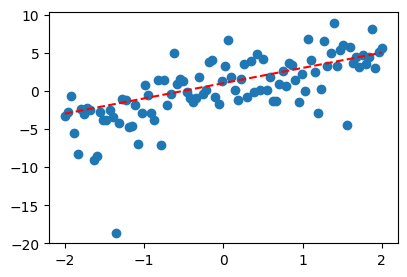

In [241]:
plt.plot(x, y, 'o')
plt.plot(x, 2*x + 1, '--r')

`-` MSE로 학습 (일반 회귀)

In [236]:
torch.manual_seed(1)
net_mse = torch.nn.Sequential(
    torch.nn.Linear(1,1)
)
loss_fn = torch.nn.MSELoss()
optimizr = torch.optim.Adam(net_mse.parameters(),lr=0.1)
#---#
for epoc in range(1000):
    ## step1
    yhat = net_mse(x)
    ## step2
    loss = loss_fn(yhat,y)
    ## step3
    loss.backward()
    ## step4
    optimizr.step()
    optimizr.zero_grad()

`-` MAE로 학습 (로버스트 회귀)

In [237]:
torch.manual_seed(1)
net_mae = torch.nn.Sequential(
    torch.nn.Linear(1,1)
)
loss_fn = torch.nn.L1Loss()
optimizr = torch.optim.Adam(net_mae.parameters(),lr=0.1)
#---#
for epoc in range(1000):
    ## step1
    yhat = net_mae(x)
    ## step2
    loss = loss_fn(yhat,y)
    ## step3
    loss.backward()
    ## step4
    optimizr.step()
    optimizr.zero_grad()

`-` 결과 비교

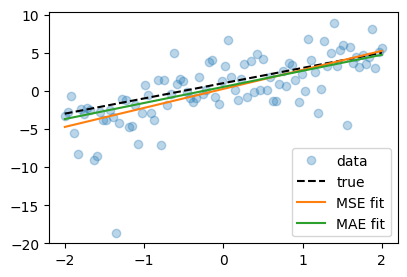

In [238]:
plt.plot(x, y, 'o', alpha=0.3, label='data')
plt.plot(x, 2*x + 1, '--', color='k', label='true')
plt.plot(x, net_mse(x).data, '-', color='C1', label='MSE fit')
plt.plot(x, net_mae(x).data, '-', color='C2', label='MAE fit')
plt.legend()

## C. 모델링 

`-` 이를 로버스트회귀라고 하며 회귀와는 다른 모형이다. 

`-` 잘 살펴보면 net의 아키텍처는 동일하다. 다른점이 있다면 오차항차이. $\Rightarrow$ 통계학과에서 모델링은 net의 아키텍처와 오차항을 모두 고려하는 개념 